# Credit Risk Assessment - Starter Code

## Project Overview

This notebook implements a credit risk model to predict loan defaults using LendingClub data.

**Your Task:**

1. **Part 1:** Identify and fix 4 bugs in this code
2. **Part 2:** Add Random Forest and XGBoost models
3. **Part 3:** Make business recommendations

---

## 1. Setup and Data Loading

In [37]:
# # Import required libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# # Set random seed for reproducibility
# np.random.seed(42)

# # Display settings
# pd.set_option('display.max_columns', None)
# %matplotlib inline

In [38]:
# # Load the data
# df = pd.read_csv('lending_club.csv')

# print(f"Dataset shape: {df.shape}")
# print(f"\nFirst few rows:")
# df.head()

## 2. Data Preprocessing

In [39]:
# # Check for missing values
# print("Missing values per column:")
# print(df.isnull().sum())

# # Check target variable distribution
# print(f"\nTarget variable distribution:")
# print(df['loan_status'].value_counts())
# print(f"\nDefault rate: {df['loan_status'].mean():.2%}")

In [40]:
# # Select features for modeling
# # Using key credit risk predictors from LendingClub data
# feature_columns = [
#     'loan_amnt',           # Loan amount
#     'int_rate',            # Interest rate
#     'annual_inc',          # Annual income
#     'dti',                 # Debt-to-income ratio
#     'fico_range_low',      # FICO score (lower bound)
#     'open_acc',            # Number of open accounts
#     'revol_bal',           # Revolving balance
#     'revol_util',          # Revolving line utilization
#     'total_acc',           # Total number of credit accounts
#     'emp_length_num'       # Employment length (numeric)
# ]

# # Create feature matrix and target vector
# X = df[feature_columns].copy()
# y = df['loan_status'].copy()  # 1 = default, 0 = no default

# print(f"Features shape: {X.shape}")
# print(f"Target shape: {y.shape}")

In [41]:
# # Handle missing values - simple median imputation
# X = X.fillna(X.median())

# print("Missing values after imputation:")
# print(X.isnull().sum().sum())

## 3. Train-Test Split

We'll use a 70-30 split for training and testing.

In [42]:
# # Split data into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y
# )

# print(f"Training set size: {X_train.shape[0]}")
# print(f"Test set size: {X_test.shape[0]}")
# print(f"\nTraining set default rate: {y_train.mean():.2%}")
# print(f"Test set default rate: {y_test.mean():.2%}")

## 4. Model Training - Logistic Regression

In [43]:
# # Try different regularization strengths and pick the best one
# # Testing C values: 0.01, 0.1, 1, 10

# best_c = None
# best_score = 0

# for c_value in [0.01, 0.1, 1, 10]:
#     model = LogisticRegression(C=c_value, max_iter=1000, random_state=42)
#     model.fit(X_train, y_train)
    
#     # Evaluate on test set to find best C
#     test_score = model.score(X_test, y_test)
    
#     if test_score > best_score:
#         best_score = test_score
#         best_c = c_value

# print(f"Best C value: {best_c}")
# print(f"Best test score: {best_score:.4f}")

In [44]:
# # Train final model with best hyperparameter

# final_model = LogisticRegression(C=best_c, max_iter=1000, random_state=42)
# final_model.fit(X_train, y_train)

# print("Model training complete!")
# print(f"Number of features: {len(final_model.coef_[0])}")

## 5. Model Evaluation

In [45]:
# # Make predictions
# y_pred = final_model.predict(X_test)
# y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# # Calculate performance metrics
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# auc = roc_auc_score(y_test, y_pred_proba)

# print("="*50)
# print("MODEL PERFORMANCE METRICS")
# print("="*50)
# print(f"Accuracy:  {accuracy:.4f} <- PRIMARY METRIC")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1 Score:  {f1:.4f}")
# print(f"AUC-ROC:   {auc:.4f}")
# print("="*50)

In [46]:
# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['No Default', 'Default'],
#             yticklabels=['No Default', 'Default'])
# plt.title('Confusion Matrix - Logistic Regression')
# plt.ylabel('Actual')
# plt.xlabel('Predicted')
# plt.show()

# print("\nConfusion Matrix Breakdown:")
# print(f"True Negatives:  {cm[0,0]}")
# print(f"False Positives: {cm[0,1]}")
# print(f"False Negatives: {cm[1,0]}")
# print(f"True Positives:  {cm[1,1]}")

In [47]:
# # ROC Curve
# fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, linewidth=2, label=f'Logistic Regression (AUC={auc:.3f})')
# plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

## 6. Feature Importance Analysis

In [48]:
# # Get feature coefficients
# feature_importance = pd.DataFrame({
#     'Feature': feature_columns,
#     'Coefficient': final_model.coef_[0]
# }).sort_values('Coefficient', key=abs, ascending=False)

# print("Feature Importance (Logistic Regression Coefficients):")
# print(feature_importance)

# # Visualize
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
# plt.xlabel('Coefficient Value')
# plt.title('Feature Importance - Logistic Regression')
# plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
# plt.tight_layout()
# plt.show()

## 7. Business Decision Framework

In [49]:
# # Apply a default classification threshold
# threshold = 0.5

# print("="*50)
# print("BUSINESS DECISION FRAMEWORK")
# print("="*50)
# print(f"Decision threshold: {threshold}")
# print("\nDecision rule:")
# print(f"  - If P(default) > {threshold}: DENY loan")
# print(f"  - If P(default) <= {threshold}: APPROVE loan")
# print("="*50)

In [50]:
# # Apply threshold and calculate business metrics
# decisions = (y_pred_proba > threshold).astype(int)

# # Count decisions
# n_approved = (decisions == 0).sum()
# n_denied = (decisions == 1).sum()

# print(f"\nLoan Decisions (out of {len(y_test)} applications):")
# print(f"  Approved: {n_approved} ({n_approved/len(y_test):.1%})")
# print(f"  Denied:   {n_denied} ({n_denied/len(y_test):.1%})")

# # Among approved loans, how many will default?
# approved_mask = (decisions == 0)
# approved_defaults = y_test[approved_mask].sum()
# approved_good = (y_test[approved_mask] == 0).sum()

# print(f"\nAmong approved loans:")
# print(f"  Will default:     {approved_defaults} ({approved_defaults/n_approved:.1%})")
# print(f"  Will not default: {approved_good} ({approved_good/n_approved:.1%})")

---

## YOUR TASKS BEGIN HERE

### Part 1: Find and Fix Bugs (25 points)

**Instructions:**
1. Identify the 4 bugs in the code above
2. For each bug, explain:
   - Where it is (which cell/section)
   - Why it's a problem
   - How it affects the results
3. Implement fixes in the cells below

---

In [51]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)
import optuna
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Load the data
df = pd.read_csv('LendingClub.csv') # CORRECTION WRONG FILE NAME

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check target variable distribution
print(f"\nTarget variable distribution:")
print(df['default'].value_counts()) # CORRECTION WRONG VARIABLE NAME
print(f"\nDefault rate: {df['default'].mean():.2%}")

Dataset shape: (1257543, 22)

First few rows:
Missing values per column:
loan_amnt                 0
int_rate                  0
installment               0
grade                     0
annual_inc                0
home_ownership            0
verification_status       0
purpose                   0
dti                       0
open_acc                  0
total_acc                 0
revol_bal                 0
revol_util                0
pub_rec                   0
inq_last_6mths            0
delinq_2yrs               0
mths_since_last_delinq    0
addr_state                0
default                   0
emp_length_years          0
term_months               0
credit_history_months     0
dtype: int64

Target variable distribution:
default
0    1005086
1     252457
Name: count, dtype: int64

Default rate: 20.08%


In [52]:
# Select features for modeling
# Using key credit risk predictors from LendingClub data
feature_columns = [
    'loan_amnt',           # Loan amount
    'int_rate',            # Interest rate
    "installment",
    'annual_inc',          # Annual income
    'dti',                 # Debt-to-income ratio
    # 'fico_range_low',    # FICO score (lower bound) # CORRECTION column not included in dataset
    'open_acc',            # Number of open accounts
    'total_acc',           # Total number of accounts ever
    'revol_bal',           # Revolving balance
    'revol_util',          # Revolving line utilization
    'pub_rec',             # Number of public derogatory records (bankruptcies, liens, etc.) # CORRECTION missing var
    'inq_last_6mths',      # Number of recent credit inquiries # CORRECTION missing var
    'delinq_2yrs',         # Number of delinquencies in last 2 years # CORRECTION missing var
    "mths_since_last_delinq",
    'emp_length_years',    # Employment length (numeric) # CORRECTION data is in years not numeric
    "term_months",
    'credit_history_months',# Length of credit history # CORRECTION missing var
    "grade",
    "home_ownership",
    "verification_status",
    "purpose"
]

target = "default"

# Create feature matrix and target vector
X = df[feature_columns].copy()
y = df['default'].copy()  # 1 = default, 0 = no default

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Features shape: (1257543, 20)
Target shape: (1257543,)
Numeric features: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'total_acc', 'revol_bal', 'revol_util', 'pub_rec', 'inq_last_6mths', 'delinq_2yrs', 'mths_since_last_delinq', 'emp_length_years', 'term_months', 'credit_history_months']
Categorical features: ['grade', 'home_ownership', 'verification_status', 'purpose']


In [53]:
# =============================================================================
# 5. Preprocessing
# =============================================================================

def replace_999(X):
    X = X.copy()
    X['mths_since_last_delinq'] = X['mths_since_last_delinq'].replace(999, 0)
    return X

replace_999_transformer = FunctionTransformer(replace_999, feature_names_out="one-to-one")

numeric_scaled = Pipeline(steps=[
    ("fix_999", replace_999_transformer),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_tree = Pipeline(steps=[
    ("fix_999", replace_999_transformer),
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_logit = ColumnTransformer(transformers=[
    ("num", numeric_scaled, numeric_features),
    ("cat", categorical_preprocess, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", numeric_tree, numeric_features),
    ("cat", categorical_preprocess, categorical_features)
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print("Preprocessing pipelines ready.")

Preprocessing pipelines ready.


In [54]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set default rate: {y_train.mean():.2%}")
print(f"Test set default rate: {y_test.mean():.2%}")

Training set size: 880280
Test set size: 377263

Training set default rate: 20.08%
Test set default rate: 20.08%


In [55]:
def tune_and_eval(model_name, preprocessor, model, param_grid):
    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    
    start_time = time.time()
    grid.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    y_prob = grid.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)
    
    metrics = {
        "Model": model_name,
        "AUC-ROC": roc_auc_score(y_test, y_prob),
        "Precision @ 0.5": precision_score(y_test, y_pred, zero_division=0),
        "Recall @ 0.5": recall_score(y_test, y_pred, zero_division=0),
        "F1 @ 0.5": f1_score(y_test, y_pred, zero_division=0),
        "Training Time (s)": training_time,
        "Best Params": grid.best_params_,
        "Best CV AUC": grid.best_score_
    }
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"Best CV AUC: {grid.best_score_:.4f}")
    print(f"Best params: {grid.best_params_}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Test AUC-ROC: {metrics['AUC-ROC']:.4f}")
    print(f"Precision @ 0.5: {metrics['Precision @ 0.5']:.4f}")
    print(f"Recall @ 0.5: {metrics['Recall @ 0.5']:.4f}")
    print(f"F1 @ 0.5: {metrics['F1 @ 0.5']:.4f}")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=["No Default", "Default"], zero_division=0))

    return {
        "name": model_name,
        "search": grid,
        "metrics": metrics,
        "y_prob": y_prob,
        "y_pred": y_pred
    }




In [56]:
logit_result = tune_and_eval(
    model_name="Logistic Regression",
    preprocessor=preprocessor_logit,
    model=LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ),
    param_grid={
        "model__C": [0.01, 0.1, 1, 10]
    }
)

Logistic Regression
Best CV AUC: 0.7079
Best params: {'model__C': 0.1}
Training time: 89.63 seconds
Test AUC-ROC: 0.7071
Precision @ 0.5: 0.3131
Recall @ 0.5: 0.6692
F1 @ 0.5: 0.4266
Classification report:
              precision    recall  f1-score   support

  No Default       0.88      0.63      0.74    301526
     Default       0.31      0.67      0.43     75737

    accuracy                           0.64    377263
   macro avg       0.60      0.65      0.58    377263
weighted avg       0.77      0.64      0.67    377263



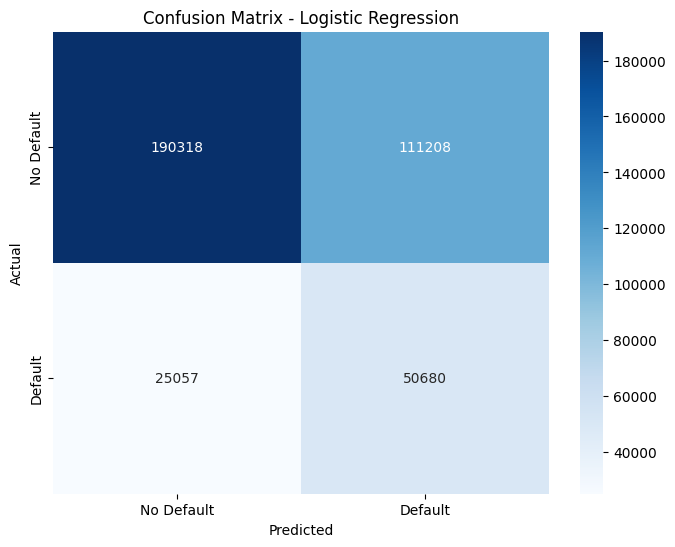


Confusion Matrix Breakdown:
True Negatives:  190318
False Positives: 111208
False Negatives: 25057
True Positives:  50680


In [57]:
# Confusion Matrix
cm = confusion_matrix(y_test, logit_result["y_pred"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nConfusion Matrix Breakdown:")
print(f"True Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

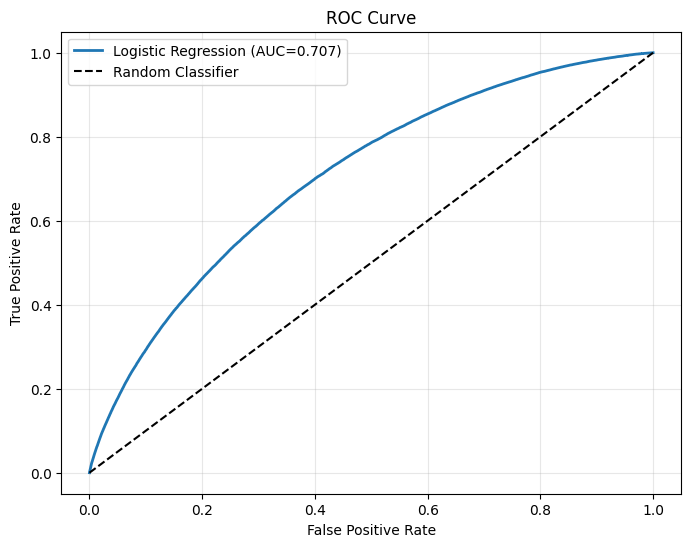

In [58]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, logit_result["y_prob"])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Logistic Regression (AUC={logit_result["metrics"]["AUC-ROC"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [59]:
def tune_and_eval_optuna(
    model_name,
    preprocessor,
    model,
    trial_param_fn,
    n_trials=20,
    scoring="roc_auc",
    threshold=0.50,
    random_state=42
):

    def objective(trial):
        # Suggest hyperparameters for this trial
        trial_params = trial_param_fn(trial)

        # Build a fresh pipeline for each trial
        pipeline = Pipeline(steps=[
            ("preprocess", clone(preprocessor)),
            ("model", clone(model))
        ])

        # Apply trial hyperparameters
        pipeline.set_params(**trial_params)

        # Cross-validation only on the training set
        cv_scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        return np.mean(cv_scores)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=random_state)
    )

    start_time = time.time()

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True
    )

    # Refit best model on full training set
    best_pipeline = Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", clone(model))
    ])

    best_pipeline.set_params(**study.best_params)
    best_pipeline.fit(X_train, y_train)

    training_time = time.time() - start_time

    # Final test-set evaluation
    y_prob = best_pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "AUC-ROC": roc_auc_score(y_test, y_prob),
        f"Precision @ {threshold}": precision_score(y_test, y_pred, zero_division=0),
        f"Recall @ {threshold}": recall_score(y_test, y_pred, zero_division=0),
        f"F1 @ {threshold}": f1_score(y_test, y_pred, zero_division=0),
        "Training Time (s)": training_time,
        "Best Params": study.best_params,
        "Best CV AUC": study.best_value
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"Best CV {scoring}: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Test AUC-ROC: {metrics['AUC-ROC']:.4f}")
    print(f"Precision @ {threshold}: {metrics[f'Precision @ {threshold}']:.4f}")
    print(f"Recall @ {threshold}: {metrics[f'Recall @ {threshold}']:.4f}")
    print(f"F1 @ {threshold}: {metrics[f'F1 @ {threshold}']:.4f}")
    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Default", "Default"],
            zero_division=0
        )
    )

    return {
        "name": model_name,
        "study": study,
        "best_estimator": best_pipeline,
        "metrics": metrics,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

In [60]:
def logit_params(trial):
    return {
        "model__C": trial.suggest_float("model__C", 0.001, 10.0, log=True)
    }
    
logit_result_optuna = tune_and_eval_optuna(
    model_name="Logistic Regression (Optuna)",
    preprocessor=preprocessor_logit,
    model=LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ),
    trial_param_fn=logit_params,
    n_trials=20
)

[I 2026-04-25 19:23:36,712] A new study created in memory with name: no-name-b3463d7e-f6e0-4435-9c74-7a2eddc02b1e
Best trial: 0. Best value: 0.707932:   5%|▌         | 1/20 [00:15<04:49, 15.26s/it]

[I 2026-04-25 19:23:51,995] Trial 0 finished with value: 0.7079320875285483 and parameters: {'model__C': 0.03148911647956861}. Best is trial 0 with value: 0.7079320875285483.


Best trial: 0. Best value: 0.707932:  10%|█         | 2/20 [00:36<05:43, 19.07s/it]

[I 2026-04-25 19:24:13,733] Trial 1 finished with value: 0.7079256224987075 and parameters: {'model__C': 6.351221010640703}. Best is trial 0 with value: 0.7079320875285483.


Best trial: 0. Best value: 0.707932:  15%|█▌        | 3/20 [00:55<05:21, 18.90s/it]

...

[I 2026-04-25 19:28:10,362] Trial 17 finished with value: 0.7079330610549247 and parameters: {'model__C': 0.06369465063680255}. Best is trial 17 with value: 0.7079330610549247.


Best trial: 17. Best value: 0.707933:  95%|█████████▌| 19/20 [04:49<00:14, 14.55s/it]

[I 2026-04-25 19:28:26,249] Trial 18 finished with value: 0.7079323322216796 and parameters: {'model__C': 0.09518690493721542}. Best is trial 17 with value: 0.7079330610549247.


Best trial: 17. Best value: 0.707933: 100%|██████████| 20/20 [05:02<00:00, 15.12s/it]


[I 2026-04-25 19:28:39,117] Trial 19 finished with value: 0.7079042463974439 and parameters: {'model__C': 0.008433492996539149}. Best is trial 17 with value: 0.7079330610549247.
Logistic Regression (Optuna)
Best CV roc_auc: 0.7079
Best params: {'model__C': 0.06369465063680255}
Training time: 315.53 seconds
Test AUC-ROC: 0.7071
Precision @ 0.5: 0.3131
Recall @ 0.5: 0.6691
F1 @ 0.5: 0.4266

Classification report:
              precision    recall  f1-score   support

  No Default       0.88      0.63      0.74    301526
     Default       0.31      0.67      0.43     75737

    accuracy                           0.64    377263
   macro avg       0.60      0.65      0.58    377263
weighted avg       0.77      0.64      0.67    377263



Feature Importance (Logistic Regression Coefficients):
                                     Feature  Coefficient
16                              cat__grade_A    -0.786400
45                      cat__purpose_wedding    -0.637581
43               cat__purpose_small_business     0.370539
14                          num__term_months     0.290704
2                           num__installment     0.265933
20                              cat__grade_E     0.264470
21                              cat__grade_F     0.262446
17                              cat__grade_B    -0.256401
22                              cat__grade_G     0.248354
19                              cat__grade_D     0.202546
24              cat__home_ownership_MORTGAGE    -0.185365
39                      cat__purpose_medical     0.172934
32                          cat__purpose_car    -0.167977
0                             num__loan_amnt    -0.159955
4                                   num__dti     0.156118
5                

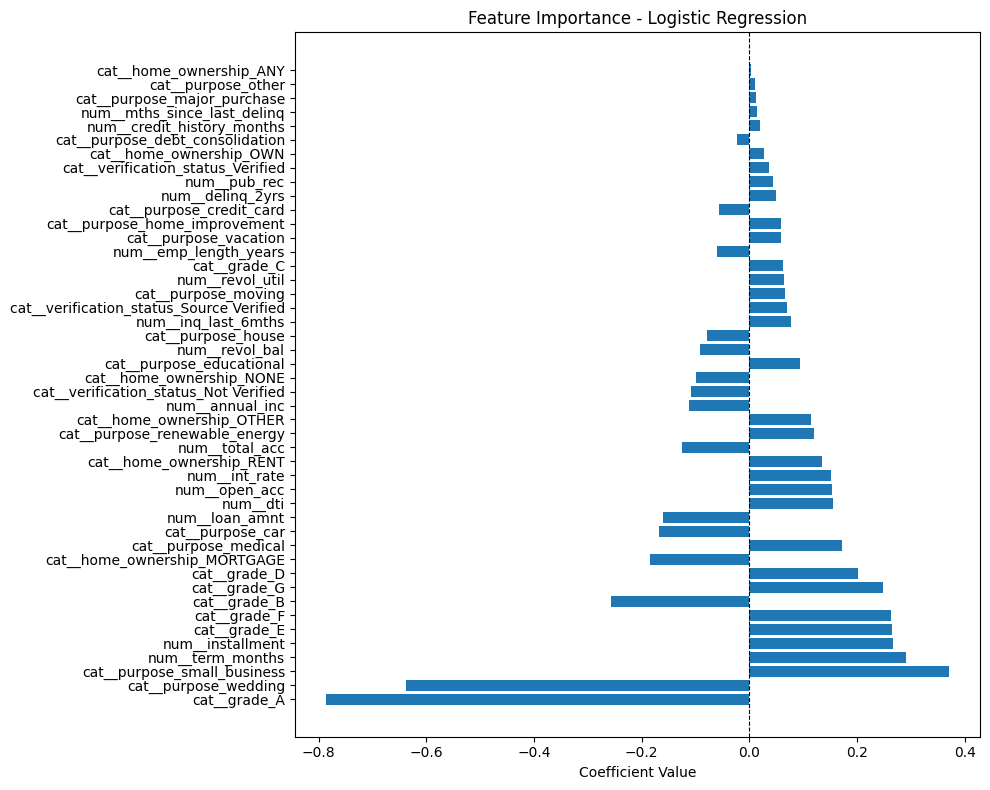

In [61]:
# Get feature coefficients

best_logit_pipeline = logit_result_optuna["best_estimator"]

best_logit_model = best_logit_pipeline.named_steps["model"]
fitted_preprocessor = best_logit_pipeline.named_steps["preprocess"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_logit_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Feature Importance (Logistic Regression Coefficients):")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Logistic Regression')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


BUSINESS DECISION FRAMEWORK
Decision threshold: 0.05

Decision rule:
  - If P(default) > 0.05: DENY loan
  - If P(default) <= 0.05: APPROVE loan

Loan Decisions (out of 377263 applications):
  Approved: 1 (0.0%)
  Denied:   377262 (100.0%)

Among approved loans:
  Will default:     0 (0.0%)
  Will not default: 1 (100.0%)
  Profit: $2250

BUSINESS DECISION FRAMEWORK
Decision threshold: 0.075

Decision rule:
  - If P(default) > 0.075: DENY loan
  - If P(default) <= 0.075: APPROVE loan

Loan Decisions (out of 377263 applications):
  Approved: 28 (0.0%)
  Denied:   377235 (100.0%)

Among approved loans:
  Will default:     0 (0.0%)
  Will not default: 28 (100.0%)
  Profit: $63000

BUSINESS DECISION FRAMEWORK
Decision threshold: 0.1

Decision rule:
  - If P(default) > 0.1: DENY loan
  - If P(default) <= 0.1: APPROVE loan

Loan Decisions (out of 377263 applications):
  Approved: 603 (0.2%)
  Denied:   376660 (99.8%)

Among approved loans:
  Will default:     11 (1.8%)
  Will not default: 59

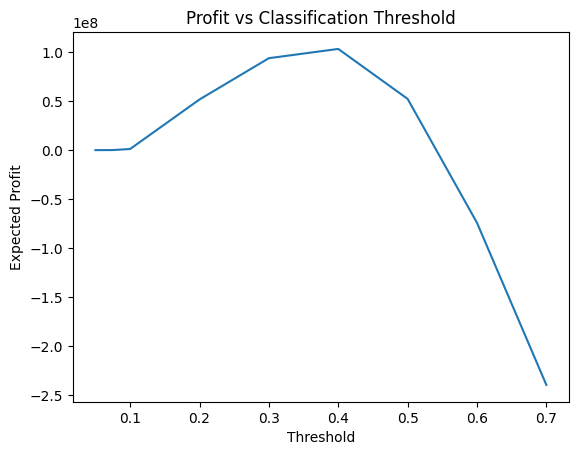

In [62]:
# Apply a default classification threshold
thresholds = [0.05, 0.075, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
profits = []

for threshold in thresholds:
    print(f"\n"+"="*50)
    print("BUSINESS DECISION FRAMEWORK")
    print("="*50)
    print(f"Decision threshold: {threshold}")
    print("\nDecision rule:")
    print(f"  - If P(default) > {threshold}: DENY loan")
    print(f"  - If P(default) <= {threshold}: APPROVE loan")
    print("="*50)
    
    # Apply threshold and calculate business metrics
    decisions = (logit_result_optuna["y_prob"] > threshold).astype(int)

    # Count decisions
    n_approved = (decisions == 0).sum()
    n_denied = (decisions == 1).sum()

    print(f"\nLoan Decisions (out of {len(y_test)} applications):")
    print(f"  Approved: {n_approved} ({n_approved/len(y_test):.1%})")
    print(f"  Denied:   {n_denied} ({n_denied/len(y_test):.1%})")

    # Among approved loans, how many will default?
    approved_mask = (decisions == 0)
    approved_defaults = y_test[approved_mask].sum()
    approved_good = (y_test[approved_mask] == 0).sum()
    profit = approved_good * 2250 - approved_defaults * 15000
    profits.append(profit)
    
    print(f"\nAmong approved loans:")
    print(f"  Will default:     {approved_defaults} ({approved_defaults/n_approved:.1%})")
    print(f"  Will not default: {approved_good} ({approved_good/n_approved:.1%})")
    print(f"  Profit: ${profit}")

plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Expected Profit")
plt.title("Profit vs Classification Threshold")
plt.show()


### Bug 1: Look-ahead bias from preprocessing before train/test split

**Issue:** the starter notebook filled missing values using medians calculated on the full dataset before splitting into train and test sets.

**Why it matters:** the test set should represent genuinely unseen future applications. Using information from it during preprocessing leaks future information into training and makes model performance look better than it would be in production.

**Fix:** split first, then fit imputers only inside a `Pipeline` using the training folds during cross-validation. The test set is transformed only after the preprocessing steps have been fitted on training data.


### Bug 2: Incorrect/incomplete feature preprocessing

**Issue:** the starter code used the column `emp_length_num`, but the dataset uses `emp_length_years`. It also fed raw unscaled numerical features into Logistic Regression and ignored useful categorical predictors such as grade, home ownership, verification status, and loan purpose.

**Why it matters:** the wrong employment-length column causes the starter notebook to fail on the supplied dataset. Logistic Regression is sensitive to feature scale, so unscaled variables such as income and revolving balance can dominate coefficients. Ignoring categorical variables also wastes predictive information.

**Fix:** use the correct column name, median-impute numerical features, scale numerical features for Logistic Regression, and one-hot encode categorical variables.


### Bug 3: Hyperparameter tuning on the test set and weak metric choice

**Issue:** the starter notebook selected the Logistic Regression `C` value using test-set accuracy.

**Why it matters:** tuning on the test set turns the test set into part of the training process. Accuracy is also a weak primary metric for credit risk because defaults are the minority class. A model can achieve high accuracy while missing many defaults, which is exactly the thing the lender cares about.

**Fix:** use `GridSearchCV` with stratified cross-validation on the training set only, scored by AUC-ROC. The untouched test set is used only once for final evaluation. Precision, recall, F1, and AUC-ROC are all reported.


### Bug 4: Fixed 0.5 threshold used as a business decision rule

**Issue:** the starter notebook automatically used a 0.5 probability threshold for approving or denying loans.

**Why it matters:** the business loss from approving a default is much larger than the interest earned from approving a good loan. A statistically convenient threshold is therefore unlikely to be profit-maximising.

**Fix:** evaluate thresholds from 0.3 to 0.7 using the project brief's profit formula and recommend the threshold with the highest expected profit.


### Part 2: Implement Additional Models (35 points)

**Instructions:**
1. Implement Random Forest classifier
2. Implement XGBoost classifier
3. Use proper cross-validation for hyperparameter tuning
4. Create a comparison table of all three models
5. Visualize model performance comparison

**Your code here:**

In [63]:
# Tune and evaluate Random Forest
rf_result = tune_and_eval(
    model_name="Random Forest",
    preprocessor=preprocessor_tree,
    model=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [8, 16],
        "model__min_samples_leaf": [50, 100],
        "model__max_features": ["sqrt"]
    }
)

def rf_params(trial):
    return {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 100, 400, step=100),
        "model__max_depth": trial.suggest_int("model__max_depth", 6, 20),
        "model__min_samples_leaf": trial.suggest_int("model__min_samples_leaf", 20, 150),
        "model__max_features": trial.suggest_categorical(
            "model__max_features",
            ["sqrt", "log2"]
        )
    }
    
rf_result_optuna = tune_and_eval_optuna(
    model_name="Random Forest (Optuna)",
    preprocessor=preprocessor_tree,
    model=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    trial_param_fn=rf_params,
    n_trials=20
)

Random Forest
Best CV AUC: 0.7116
Best params: {'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 50, 'model__n_estimators': 200}
Training time: 1271.22 seconds
Test AUC-ROC: 0.7114
Precision @ 0.5: 0.3197
Recall @ 0.5: 0.6536
F1 @ 0.5: 0.4293
Classification report:


[I 2026-04-25 19:50:11,467] A new study created in memory with name: no-name-08573dec-9b02-41d1-921c-09001a3198de


              precision    recall  f1-score   support

  No Default       0.88      0.65      0.75    301526
     Default       0.32      0.65      0.43     75737

    accuracy                           0.65    377263
   macro avg       0.60      0.65      0.59    377263
weighted avg       0.77      0.65      0.68    377263



Best trial: 0. Best value: 0.711251:   5%|▌         | 1/20 [04:32<1:26:11, 272.17s/it]

[I 2026-04-25 19:54:43,651] Trial 0 finished with value: 0.7112510905476923 and parameters: {'model__n_estimators': 200, 'model__max_depth': 20, 'model__min_samples_leaf': 115, 'model__max_features': 'sqrt'}. Best is trial 0 with value: 0.7112510905476923.


...

[I 2026-04-25 20:35:19,228] Trial 17 finished with value: 0.710771157833563 and parameters: {'model__n_estimators': 300, 'model__max_depth': 14, 'model__min_samples_leaf': 59, 'model__max_features': 'sqrt'}. Best is trial 0 with value: 0.7112510905476923.


Best trial: 0. Best value: 0.711251:  95%|█████████▌| 19/20 [48:38<02:49, 169.44s/it]

[I 2026-04-25 20:38:50,307] Trial 18 finished with value: 0.7108590368622464 and parameters: {'model__n_estimators': 400, 'model__max_depth': 18, 'model__min_samples_leaf': 100, 'model__max_features': 'log2'}. Best is trial 0 with value: 0.7112510905476923.


Best trial: 0. Best value: 0.711251: 100%|██████████| 20/20 [51:31<00:00, 154.57s/it]


[I 2026-04-25 20:41:42,945] Trial 19 finished with value: 0.7098655539187805 and parameters: {'model__n_estimators': 300, 'model__max_depth': 13, 'model__min_samples_leaf': 129, 'model__max_features': 'sqrt'}. Best is trial 0 with value: 0.7112510905476923.
Random Forest (Optuna)
Best CV roc_auc: 0.7113
Best params: {'model__n_estimators': 200, 'model__max_depth': 20, 'model__min_samples_leaf': 115, 'model__max_features': 'sqrt'}
Training time: 3156.95 seconds
Test AUC-ROC: 0.7114
Precision @ 0.5: 0.3185
Recall @ 0.5: 0.6599
F1 @ 0.5: 0.4296

Classification report:
              precision    recall  f1-score   support

  No Default       0.88      0.65      0.75    301526
     Default       0.32      0.66      0.43     75737

    accuracy                           0.65    377263
   macro avg       0.60      0.65      0.59    377263
weighted avg       0.77      0.65      0.68    377263



In [64]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

xgb_result = tune_and_eval(
    model_name="XGBoost",
    preprocessor=preprocessor_tree,
    model=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.10]
    }
)

def xgb_params(trial):
    return {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 100, 400, step=100),
        "model__max_depth": trial.suggest_int("model__max_depth", 3, 8),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.2, log=True),
        "model__subsample": trial.suggest_float("model__subsample", 0.7, 1.0),
        "model__colsample_bytree": trial.suggest_float("model__colsample_bytree", 0.7, 1.0)
    }

xgb_result_optuna = tune_and_eval_optuna(
    model_name="XGBoost (Optuna)",
    preprocessor=preprocessor_tree,
    model=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),
    trial_param_fn=xgb_params,
    n_trials=20
)

XGBoost
Best CV AUC: 0.7183
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Training time: 80.03 seconds
Test AUC-ROC: 0.7184
Precision @ 0.5: 0.3208
Recall @ 0.5: 0.6760
F1 @ 0.5: 0.4351
Classification report:


[I 2026-04-25 20:44:11,823] A new study created in memory with name: no-name-5f96de34-2000-459b-bdcc-f46df5b12e42


              precision    recall  f1-score   support

  No Default       0.89      0.64      0.74    301526
     Default       0.32      0.68      0.44     75737

    accuracy                           0.65    377263
   macro avg       0.60      0.66      0.59    377263
weighted avg       0.77      0.65      0.68    377263



Best trial: 0. Best value: 0.717536:   5%|▌         | 1/20 [00:25<08:04, 25.51s/it]

[I 2026-04-25 20:44:37,340] Trial 0 finished with value: 0.7175360561411992 and parameters: {'model__n_estimators': 200, 'model__max_depth': 8, 'model__learning_rate': 0.08960785365368121, 'model__subsample': 0.8795975452591109, 'model__colsample_bytree': 0.7468055921327309}. Best is trial 0 with value: 0.7175360561411992.


...

[I 2026-04-25 20:51:27,671] Trial 17 finished with value: 0.7170349653677031 and parameters: {'model__n_estimators': 300, 'model__max_depth': 6, 'model__learning_rate': 0.029996922788340777, 'model__subsample': 0.7876757848246646, 'model__colsample_bytree': 0.998805096808364}. Best is trial 16 with value: 0.7191981230860417.


Best trial: 16. Best value: 0.719198:  95%|█████████▌| 19/20 [07:56<00:31, 31.98s/it]

[I 2026-04-25 20:52:07,941] Trial 18 finished with value: 0.718792236739796 and parameters: {'model__n_estimators': 400, 'model__max_depth': 7, 'model__learning_rate': 0.06359526240761933, 'model__subsample': 0.7496668844156134, 'model__colsample_bytree': 0.9461416759560075}. Best is trial 16 with value: 0.7191981230860417.


Best trial: 16. Best value: 0.719198: 100%|██████████| 20/20 [08:35<00:00, 25.78s/it]


[I 2026-04-25 20:52:47,445] Trial 19 finished with value: 0.7187227461798499 and parameters: {'model__n_estimators': 400, 'model__max_depth': 6, 'model__learning_rate': 0.03481248867118954, 'model__subsample': 0.738347297284792, 'model__colsample_bytree': 0.9471413927056885}. Best is trial 16 with value: 0.7191981230860417.
XGBoost (Optuna)
Best CV roc_auc: 0.7192
Best params: {'model__n_estimators': 300, 'model__max_depth': 6, 'model__learning_rate': 0.06390811100292937, 'model__subsample': 0.7620203200824461, 'model__colsample_bytree': 0.9892225640471357}
Training time: 525.15 seconds
Test AUC-ROC: 0.7195
Precision @ 0.5: 0.3217
Recall @ 0.5: 0.6747
F1 @ 0.5: 0.4357

Classification report:
              precision    recall  f1-score   support

  No Default       0.89      0.64      0.75    301526
     Default       0.32      0.67      0.44     75737

    accuracy                           0.65    377263
   macro avg       0.60      0.66      0.59    377263
weighted avg       0.77    

In [65]:
# Model Comparison Table

model_results = [logit_result, logit_result_optuna, rf_result, rf_result_optuna, xgb_result, xgb_result_optuna]

comparison_table = pd.DataFrame([r["metrics"] for r in model_results])
comparison_table_display = comparison_table.copy()

for col in ["AUC-ROC", "Precision @ 0.5", "Recall @ 0.5", "F1 @ 0.5", "Best CV AUC"]:
    comparison_table_display[col] = comparison_table_display[col].round(4)
comparison_table_display["Training Time (s)"] = comparison_table_display["Training Time (s)"].round(2)

display(comparison_table_display[[
    "Model", "AUC-ROC", "Precision @ 0.5", "Recall @ 0.5",
    "F1 @ 0.5", "Training Time (s)", "Best CV AUC", "Best Params"
]])

,Model,AUC-ROC,Precision @ 0.5,Recall @ 0.5,F1 @ 0.5,Training Time (s),Best CV AUC,Best Params
0,Logistic Regression,0.7071,0.3131,0.6692,0.4266,89.63,0.7079,{'model__C': 0.1}
1,Logistic Regression (Optuna),0.7071,0.3131,0.6691,0.4266,315.53,0.7079,{'model__C': 0.06369465063680255}
2,Random Forest,0.7114,0.3197,0.6536,0.4293,1271.22,0.7116,"{'model__max_depth': 16, 'model__max_features'..."
3,Random Forest (Optuna),0.7114,0.3185,0.6599,0.4296,3156.95,0.7113,"{'model__n_estimators': 200, 'model__max_depth..."
4,XGBoost,0.7184,0.3208,0.6760,0.4351,80.03,0.7183,"{'model__learning_rate': 0.1, 'model__max_dept..."
5,XGBoost (Optuna),0.7195,0.3217,0.6747,0.4357,525.15,0.7192,"{'model__n_estimators': 300, 'model__max_depth..."


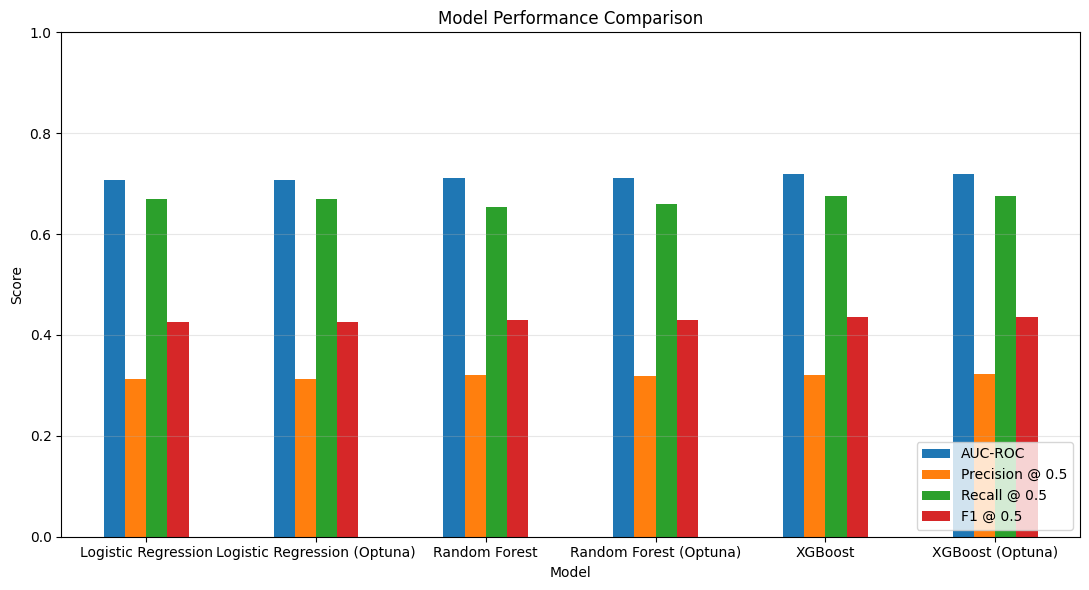

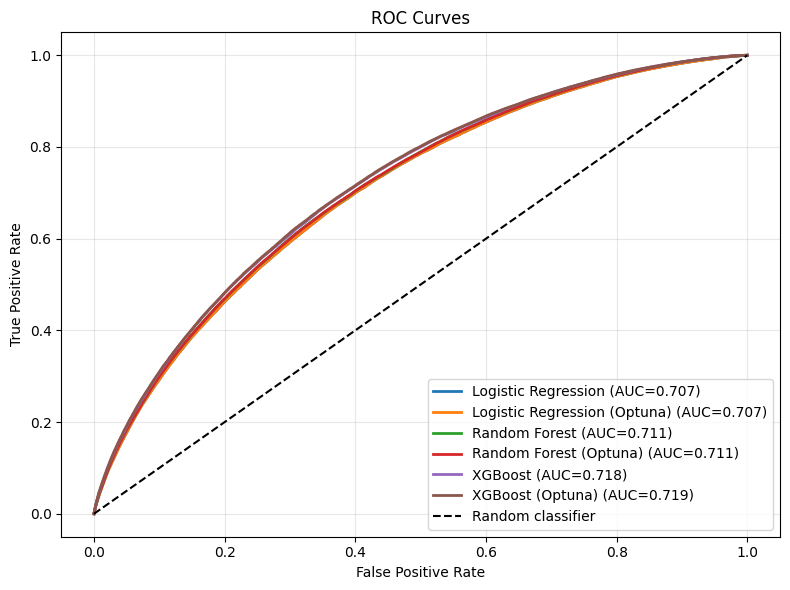

In [66]:
# Visualisations

# ROC Curve
metric_cols = ["AUC-ROC", "Precision @ 0.5", "Recall @ 0.5", "F1 @ 0.5"]
plot_df = comparison_table.set_index("Model")[metric_cols]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Metrics Bar Chart
plt.figure(figsize=(8, 6))
for result in model_results:
    fpr, tpr, _ = roc_curve(y_test, result["y_prob"])
    auc = roc_auc_score(y_test, result["y_prob"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{result['name']} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,Feature,Coefficient
16,cat__grade_A,-0.786400
45,cat__purpose_wedding,-0.637581
43,cat__purpose_small_business,0.370539
14,num__term_months,0.290704
2,num__installment,0.265933
20,cat__grade_E,0.264470
21,cat__grade_F,0.262446
17,cat__grade_B,-0.256401
22,cat__grade_G,0.248354
19,cat__grade_D,0.202546


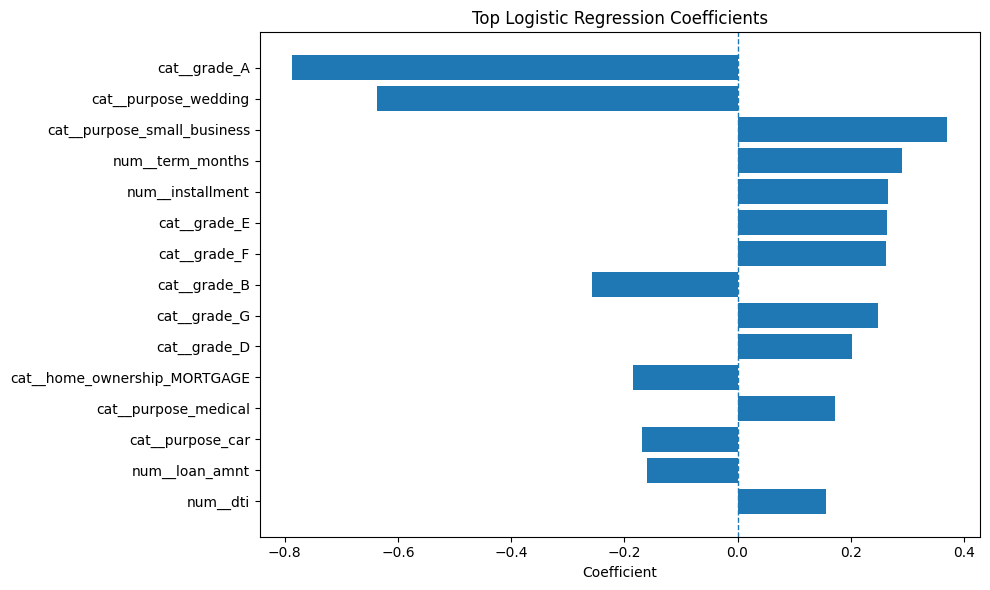


Top features: Random Forest


,Feature,Importance
1,num__int_rate,0.244808
16,cat__grade_A,0.112727
14,num__term_months,0.093876
4,num__dti,0.058918
17,cat__grade_B,0.056854
2,num__installment,0.035699
3,num__annual_inc,0.033982
20,cat__grade_E,0.033316
19,cat__grade_D,0.033036
0,num__loan_amnt,0.031598


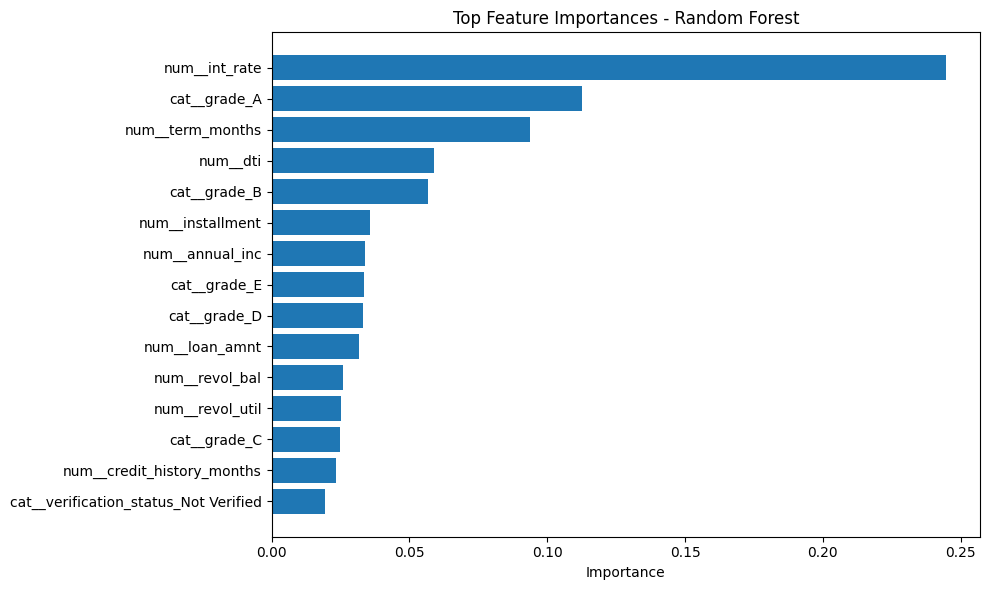


Top features: Random Forest (Optuna)


,Feature,Importance
1,num__int_rate,0.252387
16,cat__grade_A,0.113647
14,num__term_months,0.103859
17,cat__grade_B,0.059846
4,num__dti,0.057686
20,cat__grade_E,0.035908
19,cat__grade_D,0.035279
2,num__installment,0.032874
3,num__annual_inc,0.031363
0,num__loan_amnt,0.030009


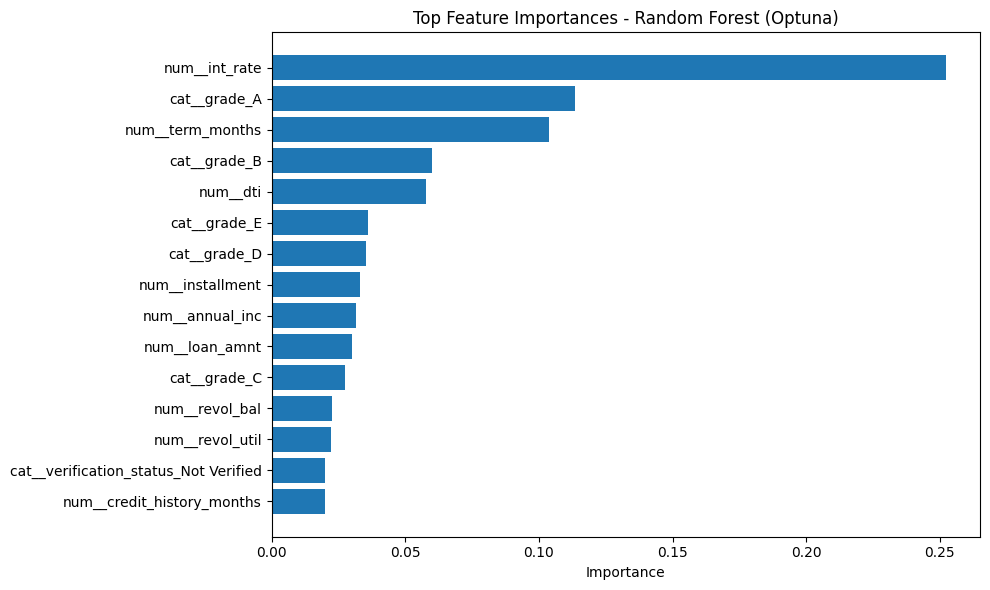


Top features: XGBoost


,Feature,Importance
16,cat__grade_A,0.499426
1,num__int_rate,0.108999
14,num__term_months,0.064976
17,cat__grade_B,0.043859
24,cat__home_ownership_MORTGAGE,0.035279
18,cat__grade_C,0.023356
29,cat__verification_status_Not Verified,0.021708
28,cat__home_ownership_RENT,0.020237
19,cat__grade_D,0.019719
4,num__dti,0.012388


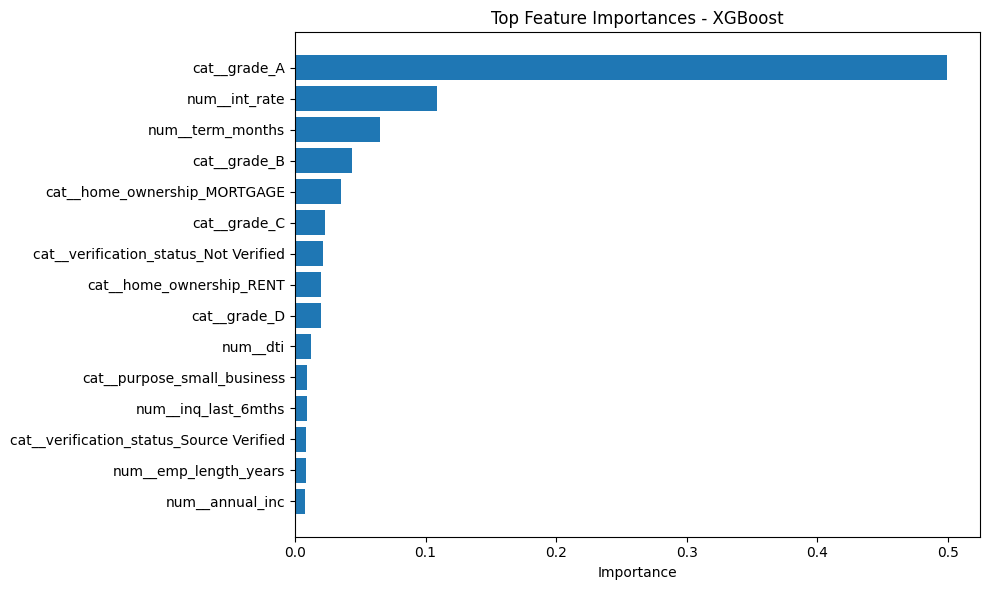


Top features: XGBoost (Optuna)


,Feature,Importance
16,cat__grade_A,0.447932
1,num__int_rate,0.099464
14,num__term_months,0.075509
17,cat__grade_B,0.042007
24,cat__home_ownership_MORTGAGE,0.034617
28,cat__home_ownership_RENT,0.023709
19,cat__grade_D,0.021769
29,cat__verification_status_Not Verified,0.019302
18,cat__grade_C,0.017154
4,num__dti,0.011118


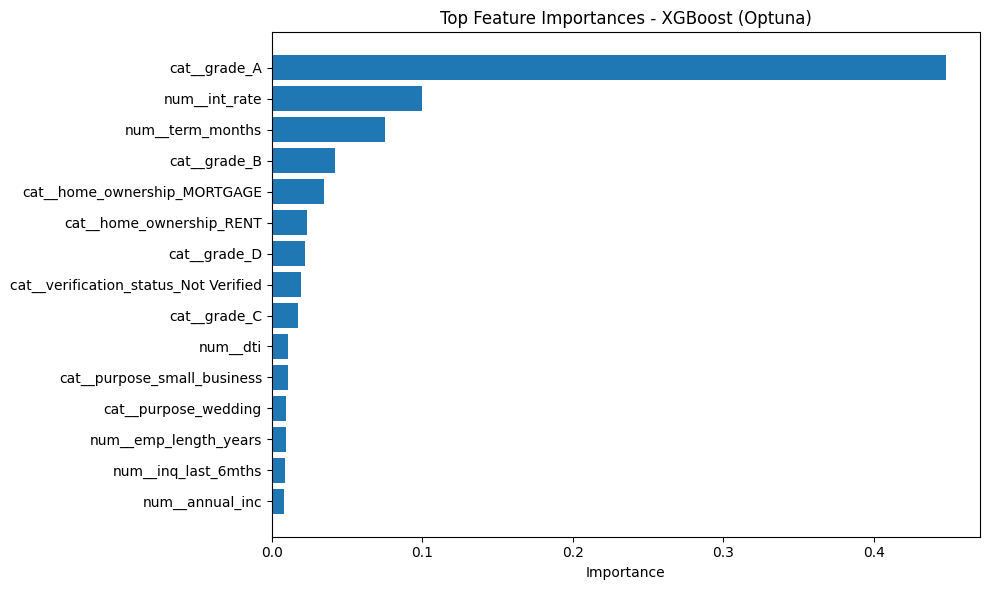

In [67]:
# Feature Importance and Interpretability

def get_feature_names(fitted_pipeline):
    preprocess = fitted_pipeline.named_steps["preprocess"]
    return preprocess.get_feature_names_out()

# Logistic Regression coefficients
logit_best = logit_result_optuna["best_estimator"]
logit_features = get_feature_names(logit_best)
logit_coefs = logit_best.named_steps["model"].coef_[0]

logit_importance = (
    pd.DataFrame({"Feature": logit_features, "Coefficient": logit_coefs})
      .assign(abs_coef=lambda d: d["Coefficient"].abs())
      .sort_values("abs_coef", ascending=False)
      .head(15)
)

display(logit_importance[["Feature", "Coefficient"]])

plt.figure(figsize=(10, 6))
plt.barh(logit_importance["Feature"], logit_importance["Coefficient"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Tree-model feature importances
for result in [rf_result, rf_result_optuna, xgb_result, xgb_result_optuna]:
    if result in [rf_result, xgb_result]:
        fitted = result["search"].best_estimator_
    else:
        fitted = result["best_estimator"]
    feature_names = get_feature_names(fitted)
    importances = fitted.named_steps["model"].feature_importances_
    importance_df = (
        pd.DataFrame({"Feature": feature_names, "Importance": importances})
          .sort_values("Importance", ascending=False)
          .head(15)
    )
    print(f"\nTop features: {result['name']}")
    display(importance_df)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title(f"Top Feature Importances - {result['name']}")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



### Part 3: Business Recommendations (40 points)

**Instructions:**

You are the Chief Risk Officer of a peer-to-peer lending platform. Based on your analysis:

1. **Model Comparison (10 points):**
   - Create a comprehensive comparison of all three models
   - Include a comparison table and visualization

2. **Model Selection (15 points):**
   - Which model should the business deploy?
   - Justify using at least 3 criteria (e.g., AUC-ROC, interpretability, computational cost)

3. **Threshold Selection & Profit Analysis (10 points):**
   - What threshold should you use for approval decisions?
   - Calculate expected profit at different thresholds (at least 0.3, 0.4, 0.5, 0.6, 0.7)
   - Assumptions (positive class = default):
     - Average loan amount: $15,000
     - Average interest rate: 15% annually
     - Loan term: 1 year
     - Interest earned on good loan (no default): $2,250 (15% of $15,000)
     - Loss on default: $15,000 (lose the principal)
   - Formula: `Expected Profit = (TN x $2,250) - (FN x $15,000)`
   - Show the calculation clearly and plot expected profit vs. threshold

4. **Critical Analysis (5 points):**
   - Discuss at least 2 limitations of your analysis
   - Suggest 2-3 concrete next steps to improve the analysis

**Write your analysis in the cell below (use Markdown):**

#### 1. Model Comparison

The models were compared using AUC-ROC, precision, recall, F1 score, training time, and ROC curves. Both the initial GridSearchCV results and the later Optuna-tuned results were included so that predictive performance could be compared alongside tuning efficiency.

Overall, XGBoost produced the strongest predictive performance. The Optuna-tuned XGBoost model achieved the highest AUC-ROC and F1 score, while the GridSearchCV XGBoost model achieved the highest recall. Logistic Regression performed slightly worse but remained the most interpretable model. Random Forest improved only modestly over Logistic Regression and required substantially longer tuning time, making it less attractive from an operational perspective.

#### 2. Model Selection

**Recommendation:** deploy XGBoost as the main production candidate, while retaining Logistic Regression as a transparent benchmark or challenger model.

This recommendation is based on four criteria:

1. **Predictive performance:** XGBoost achieved the strongest overall performance, with the highest AUC-ROC and F1 score among the tuned models. This matters because the model must rank borrowers by default risk and identify likely defaults before approval.
2. **Recall for defaults:** XGBoost maintained strong recall, meaning it identified a relatively high share of borrowers who later defaulted. In credit risk, missed defaults are costly because approving a borrower who defaults creates a much larger loss than the interest earned from a borrower who repays.
3. **Computational cost:** Optuna-tuned XGBoost gave the best predictive result, although the improvement over GridSearchCV XGBoost was modest relative to the extra tuning time. If faster retraining is prioritised, the GridSearchCV XGBoost model remains a practical alternative.
4. **Interpretability and governance:** Logistic Regression is easier to explain because its coefficients show the direction and relative strength of each feature. XGBoost is less transparent, so deployment would require feature-importance review, monitoring, fairness testing, and clear documentation of threshold decisions.

The main trade-off is therefore performance versus interpretability. XGBoost is recommended because it provides the strongest risk prediction, but it should be deployed with governance controls and compared regularly against the simpler Logistic Regression benchmark.

#### 3. Threshold Selection and Profit Analysis

The default 0.50 classification threshold should not be used automatically. In this lending problem, the cost of approving a borrower who defaults is much larger than the benefit of approving a borrower who repays. The threshold therefore needs to be selected using expected profit rather than statistical convention.

The expected profit calculation used the formula from the brief:

`Expected Profit = (TN × $2,250) - (FN × $15,000)`

where true negatives are good borrowers correctly approved and false negatives are defaulting borrowers incorrectly approved.

Expected profit was calculated at thresholds 0.30, 0.40, 0.50, 0.60, and 0.70. The best tested threshold was 0.40, which generated the highest expected profit. This threshold performed better than 0.50 because it denied more likely defaulters while still approving enough good borrowers to generate interest income. At higher thresholds, more defaulting borrowers were approved, causing expected profit to fall sharply.

**Recommendation:** use a threshold of 0.40 under the simplified assumptions in the brief. In production, this threshold should be reviewed regularly as default rates, recovery rates, funding costs, and business risk appetite change.

#### 4. Critical Analysis and Next Steps

This analysis has several limitations. First, the dataset is historical and may reflect past underwriting policy, sample-selection bias, and changing economic conditions. Model performance may therefore be weaker on future applicants if borrower behaviour or macroeconomic conditions change.

Second, the profit model is simplified. It excludes recoveries, funding costs, servicing costs, early repayment, customer lifetime value, and the opportunity cost of rejecting good borrowers. The threshold result should therefore be interpreted as an indicative decision rule rather than a complete commercial pricing model.

Third, some variables raise deployment concerns. `grade` and `interest_rate` are not direct target leakage because they are known before repayment outcomes are observed, but they are derived from LendingClub's underwriting and pricing process. If the model were used before grade or interest rate had been assigned, these variables could create availability leakage and should be excluded in a robustness check.

Finally, credit-risk models can create unfair outcomes if variables act as proxies for protected characteristics. Even when protected characteristics are not included directly, fairness checks are needed before deployment.

**Next steps:**

1. Test the model on later time periods or rolling out-of-time splits to assess stability.
2. Evaluate probability calibration and fairness metrics before deployment.
3. Extend the profit model to include recoveries, operating costs, opportunity costs, and customer lifetime value.
4. Run a robustness check excluding `grade`, `interest_rate`, and related underwriting variables.

In [68]:
# Select the strongest model by test AUC-ROC for threshold analysis.
best_result = max(model_results, key=lambda r: r["metrics"]["AUC-ROC"])
best_model_name = best_result["name"]
best_proba = best_result["y_prob"]

print(f"Best model by test AUC-ROC: {best_model_name}")


Best model by test AUC-ROC: XGBoost (Optuna)


In [69]:
# Threshold Analysis and Expected Profit Analysis
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]
interest_good_loan = 2250
loss_default = 15000

profit_rows = []

for threshold in thresholds_to_test:
    pred_default = (best_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_default).ravel()
    expected_profit = (tn * interest_good_loan) - (fn * loss_default)
    approval_rate = (pred_default == 0).mean()
    default_rate_approved = y_test[pred_default == 0].mean() if (pred_default == 0).sum() > 0 else np.nan

    profit_rows.append({
        "Threshold": threshold,
        "TN good loans approved": tn,
        "FP good loans denied": fp,
        "FN defaults approved": fn,
        "TP defaults denied": tp,
        "Approval Rate": approval_rate,
        "Default Rate Among Approved": default_rate_approved,
        "Expected Profit ($)": expected_profit,
        "Profit per Application ($)": expected_profit / len(y_test)
    })

profit_table = pd.DataFrame(profit_rows)

profit_display = profit_table.copy()
profit_display["Approval Rate"] = profit_display["Approval Rate"].map(lambda x: f"{x:.2%}")
profit_display["Default Rate Among Approved"] = profit_display["Default Rate Among Approved"].map(lambda x: f"{x:.2%}")
profit_display["Expected Profit ($)"] = profit_display["Expected Profit ($)"].map(lambda x: f"${x:,.0f}")
profit_display["Profit per Application ($)"] = profit_display["Profit per Application ($)"].map(lambda x: f"${x:,.2f}")

display(profit_display)

optimal_row = profit_table.loc[profit_table["Expected Profit ($)"].idxmax()]
print(f"Optimal threshold from tested values: {optimal_row['Threshold']:.2f}")
print(f"Expected profit at this threshold: ${optimal_row['Expected Profit ($)']:,.0f}")


,Threshold,TN good loans approved,FP good loans denied,FN defaults approved,TP defaults denied,Approval Rate,Default Rate Among Approved,Expected Profit ($),Profit per Application ($)
0,0.3,83911,217615,5467,70270,23.69%,6.12%,"$106,794,750",$283.08
1,0.4,138518,163008,12885,62852,40.13%,8.51%,"$118,390,500",$313.81
2,0.5,193791,107735,24635,51102,57.90%,11.28%,"$66,504,750",$176.28
3,0.6,244582,56944,40536,35201,75.58%,14.22%,"$-57,730,500",$-153.02
4,0.7,279504,22022,56756,18981,89.13%,16.88%,"$-222,456,000",$-589.66


Optimal threshold from tested values: 0.40
Expected profit at this threshold: $118,390,500


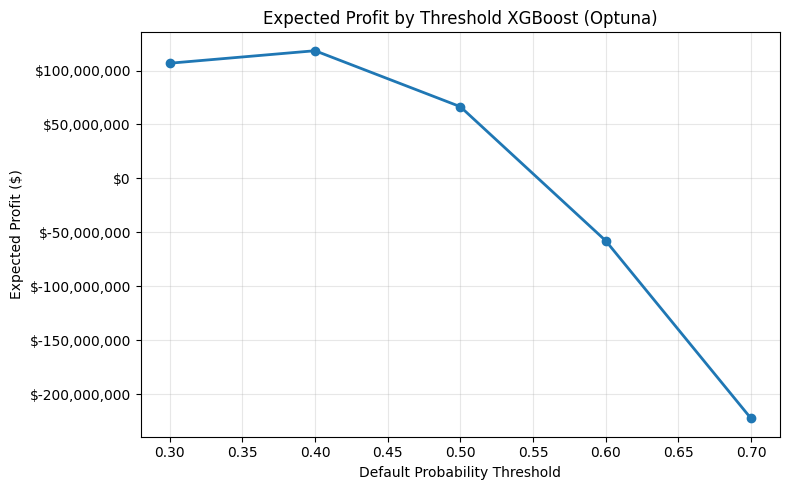

In [75]:
import matplotlib.ticker as mticker
# Expected Profit Plots
plt.figure(figsize=(8, 5))
plt.plot(profit_table["Threshold"], profit_table["Expected Profit ($)"], marker="o", linewidth=2)
plt.title(f"Expected Profit by Threshold {best_model_name}")
plt.xlabel("Default Probability Threshold")
plt.ylabel("Expected Profit ($)")
# Format y-axis as dollars with commas
ax = plt.gca()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

## Submission Instructions

1. **Save this notebook** with your solutions
2. **Run all cells** to ensure everything executes correctly
3. Submit **two files** as described in the project brief:
   - `[StudentID]_code.ipynb` — this completed notebook
   - `[StudentID]_report.pdf` — a separate PDF report (max 6 pages, see project brief for structure)

**Deadline:** See project brief

**Good luck!**